# Prac 07.1
Traffic sign binary classifier using a neural network (TensorFlow/Keras).

### Step 0 — Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import cv2
import numpy as np
from sklearn.utils import shuffle
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

plt.rcParams['figure.figsize'] = [15, 6]

### Step 1 — Load and visualise examples from `data/subset_homework`

The dataset contains two classes of traffic signs (class 0 and class 1), each stored in its own folder.

In [2]:
folder = '../data/subset_homework'

# Load class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

# Load class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

print(f'Class 0 images: {len(images_0)}')
print(f'Class 1 images: {len(images_1)}')
print(f'Total: {len(images_0) + len(images_1)}')
print(f'Image size: {images_0[0].shape}')

Class 0 images: 2220
Class 1 images: 2250
Total: 4470
Image size: (28, 28)


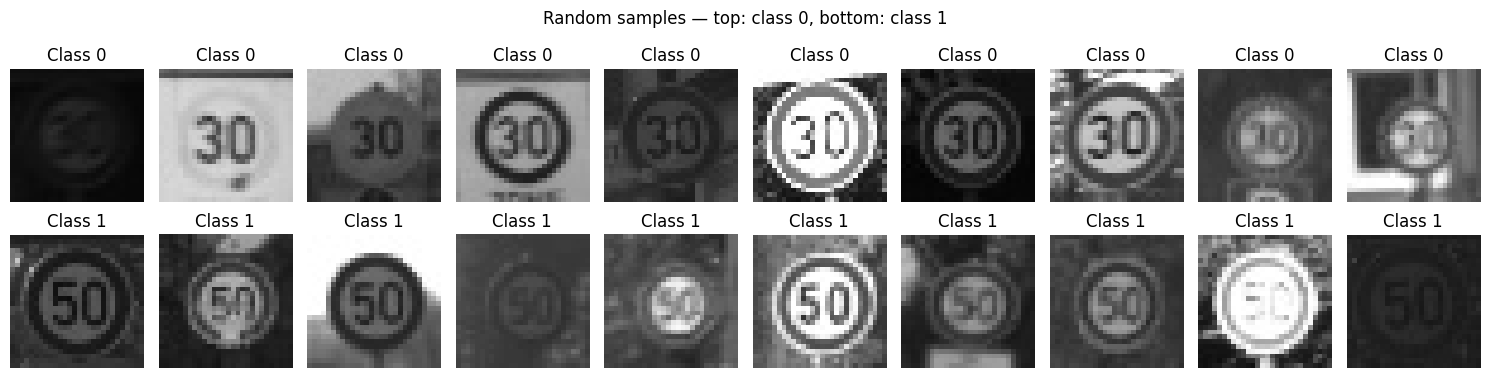

In [3]:
# Visualise random samples from each class
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
np.random.seed(0)
for col, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    axes[0, col].imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title('Class 0')
    axes[0, col].axis('off')
for col, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    axes[1, col].imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_title('Class 1')
    axes[1, col].axis('off')
plt.suptitle('Random samples — top: class 0, bottom: class 1')
plt.tight_layout()

### Prepare input data

In [4]:
# Combine, shuffle, and convert to numpy
images, labels = shuffle(images_0 + images_1, labels_0 + labels_1, random_state=42)
images = np.array(images)
labels = np.array(labels)

# Flatten 28x28 -> 784 and normalise to [0, 1]
pixels = np.array([img.flatten() for img in images], dtype=np.float32) / 255.0

print('pixels shape:', pixels.shape)
print('labels shape:', labels.shape)

pixels shape: (4470, 784)
labels shape: (4470,)


### Step 2 — Single-neuron model

Following the lecture, we build the simplest possible network: a single Dense layer with one output
neuron and linear activation. The model is trained with MSE loss.

In [5]:
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation='linear')(inputs)
model1 = Model(inputs, outputs)
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - loss: 0.3107
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 0.2347
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - loss: 0.1864
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 0.1612
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.1457
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - loss: 0.1288
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - loss: 0.1168
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - loss: 0.1091
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 0.1033
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 0.1040


Text(0.5, 1.0, 'Single-neuron model — training loss')

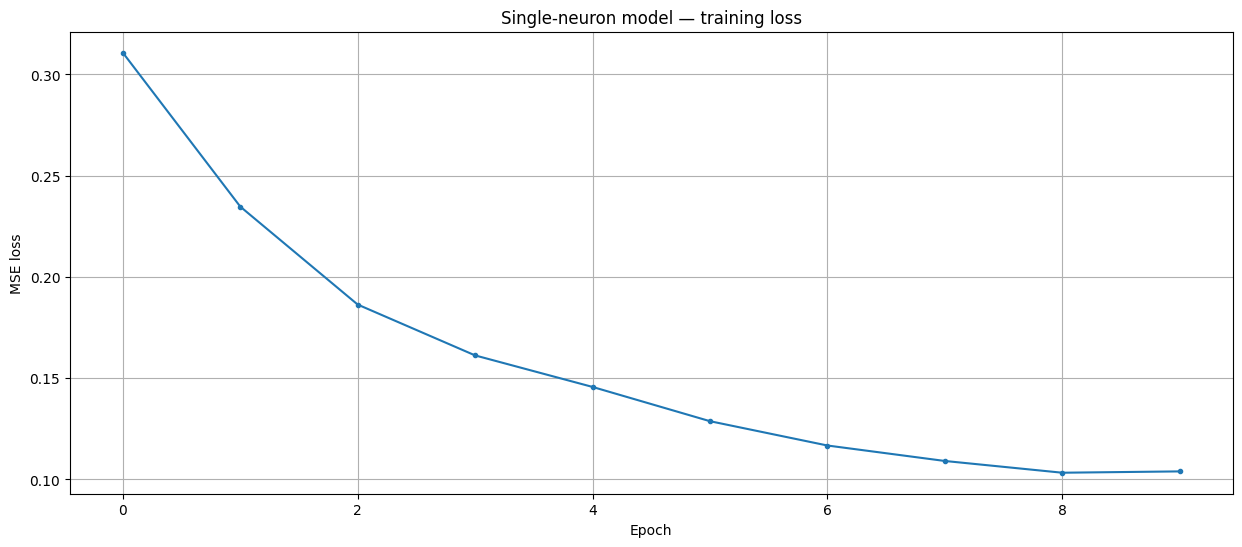

In [6]:
model1.compile(optimizer='adam', loss='mean_squared_error')
history1 = model1.fit(pixels, labels, epochs=10, batch_size=32)

# Plot training loss
plt.plot(history1.history['loss'], '.-')
plt.xlabel('Epoch'), plt.ylabel('MSE loss'), plt.grid(True)
plt.title('Single-neuron model — training loss')

In [7]:
# Evaluate accuracy (threshold at 0.5)
preds1 = (model1.predict(pixels).squeeze() > 0.5).astype(int)
acc1 = np.mean(preds1 == labels)
print(f'Single-neuron accuracy: {acc1:.4f}  ({acc1*100:.1f}%)')

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step
Single-neuron accuracy: 0.9058  (90.6%)


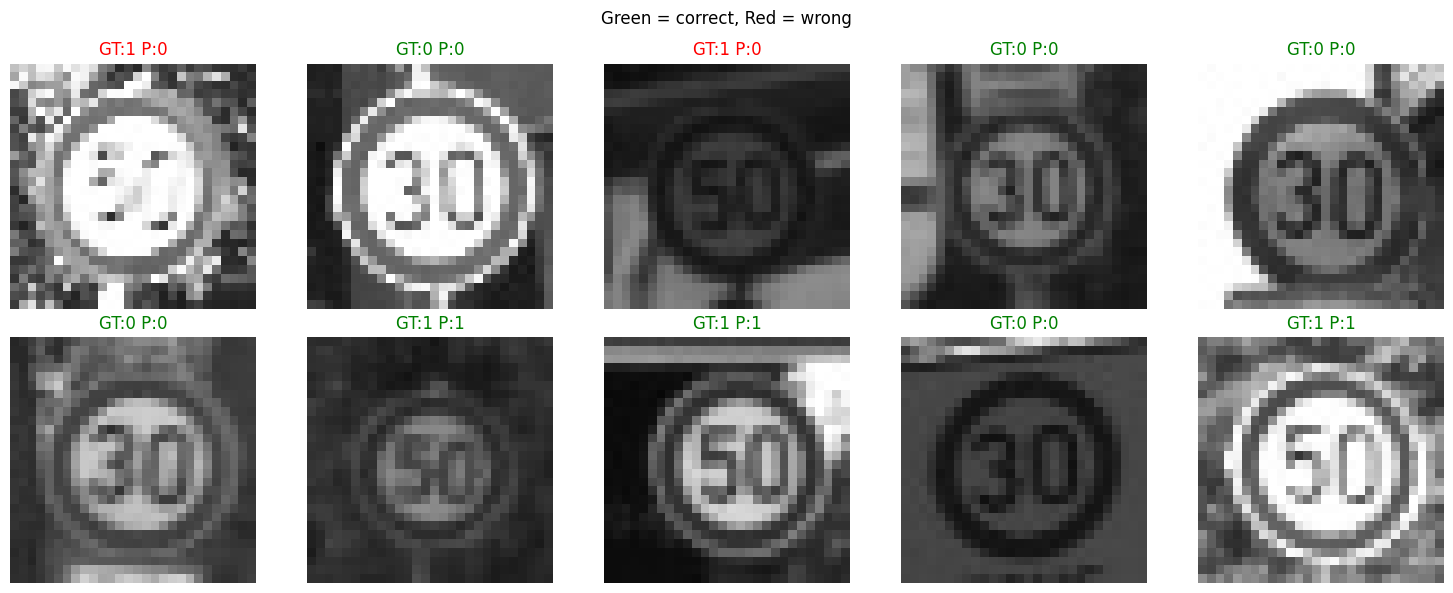

In [8]:
# Visualise some predictions
np.random.seed(1)
idxs = np.random.randint(0, len(images), 10)
for cnt, idx in enumerate(idxs):
    plt.subplot(2, 5, cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    color = 'green' if preds1[idx] == labels[idx] else 'red'
    plt.title(f'GT:{labels[idx]} P:{preds1[idx]}', color=color)
    plt.axis('off')
plt.suptitle('Green = correct, Red = wrong')
plt.tight_layout()

### Step 3 — Improved model

We improve accuracy by:
- Adding two hidden layers (Dense 64 + Dense 32) with ReLU activations
- Using sigmoid output activation (proper for binary classification)
- Switching from MSE to **binary cross-entropy** loss
- Training for 20 epochs

In [9]:
inputs2 = Input(shape=(pixels.shape[1],))
x = Dense(64, activation='relu')(inputs2)
x = Dense(32, activation='relu')(x)
outputs2 = Dense(1, activation='sigmoid')(x)
model2 = Model(inputs2, outputs2)
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,353 (204.50 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - accuracy: 0.6333 - loss: 0.6334
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.7528 - loss: 0.5213
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.8548 - loss: 0.3829
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.8857 - loss: 0.2998
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - accuracy: 0.9094 - loss: 0.2498
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.9416 - loss: 0.1904
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - accuracy: 0.9161 - loss: 0.2269
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - accuracy: 0.9438 - loss: 0.1701
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.9385 - loss: 0.1712
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.9452 - loss: 0.1566
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.9443 - loss: 0.1615
Epoch 12/20
140/140 ━━━━━━━━━━

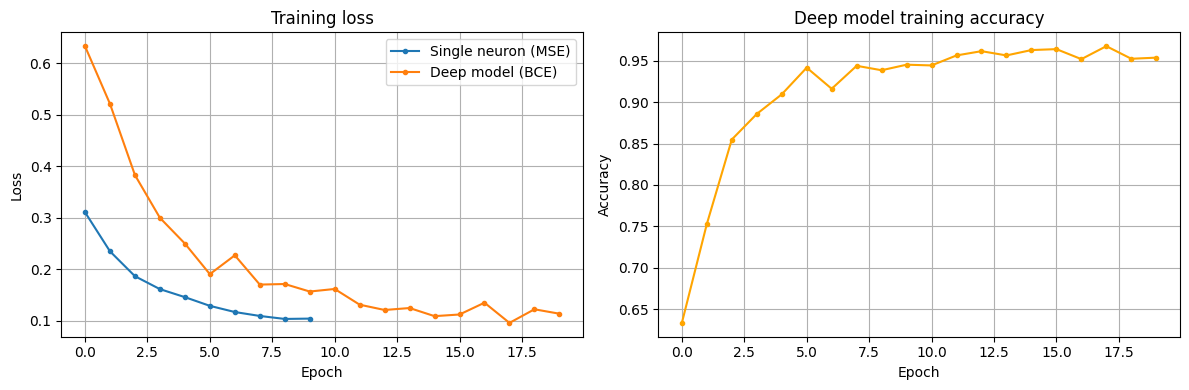

In [10]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(pixels, labels, epochs=20, batch_size=32)

# Compare training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history1.history['loss'], '.-', label='Single neuron (MSE)')
axes[0].plot(history2.history['loss'], '.-', label='Deep model (BCE)')
axes[0].set_xlabel('Epoch'), axes[0].set_ylabel('Loss')
axes[0].legend(), axes[0].grid(True)
axes[0].set_title('Training loss')

axes[1].plot(history2.history['accuracy'], '.-', color='orange')
axes[1].set_xlabel('Epoch'), axes[1].set_ylabel('Accuracy')
axes[1].grid(True)
axes[1].set_title('Deep model training accuracy')
plt.tight_layout()

In [11]:
preds2 = (model2.predict(pixels).squeeze() > 0.5).astype(int)
acc2 = np.mean(preds2 == labels)
print(f'Single-neuron accuracy : {acc1:.4f}  ({acc1*100:.1f}%)')
print(f'Deep model accuracy    : {acc2:.4f}  ({acc2*100:.1f}%)')
print(f'Improvement            : +{(acc2-acc1)*100:.1f} pp')

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step
Single-neuron accuracy : 0.9058  (90.6%)
Deep model accuracy    : 0.9345  (93.4%)
Improvement            : +2.9 pp


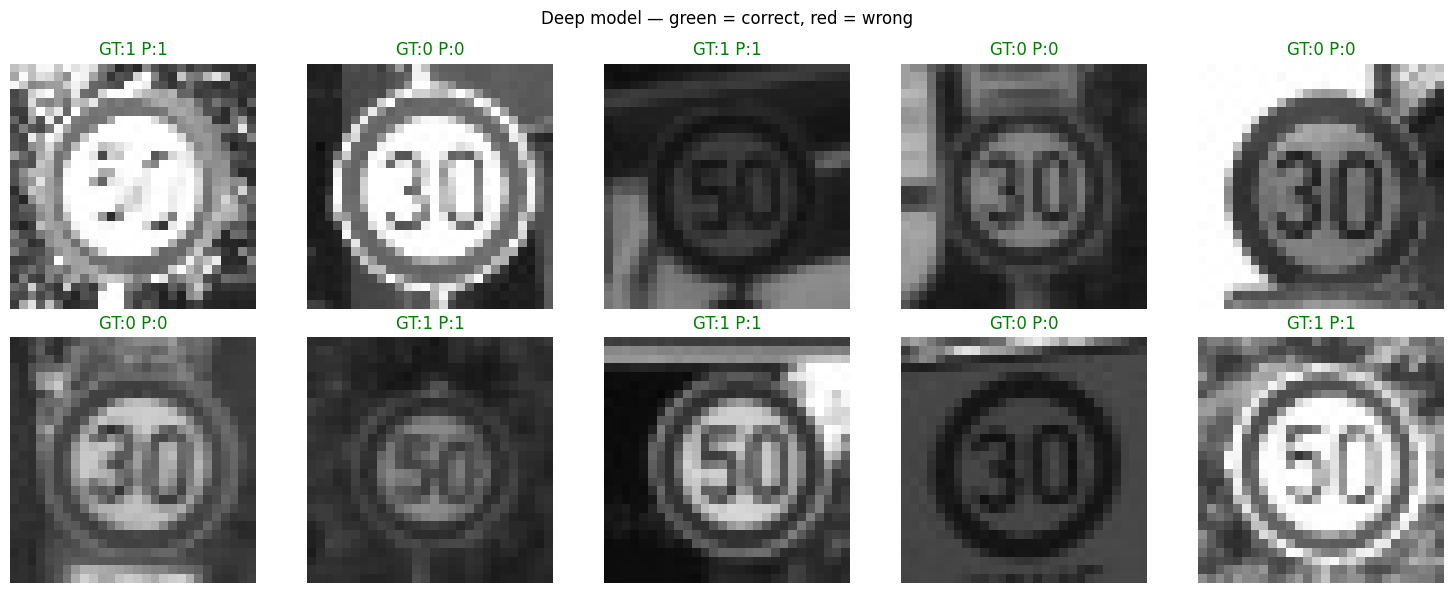

In [12]:
# Visualise deep model predictions
np.random.seed(1)
idxs = np.random.randint(0, len(images), 10)
for cnt, idx in enumerate(idxs):
    plt.subplot(2, 5, cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    color = 'green' if preds2[idx] == labels[idx] else 'red'
    plt.title(f'GT:{labels[idx]} P:{preds2[idx]}', color=color)
    plt.axis('off')
plt.suptitle('Deep model — green = correct, red = wrong')
plt.tight_layout()

**Summary:**

| Model | Architecture | Loss | Epochs | Accuracy |
|---|---|---|---|---|
| Single neuron | Input → Dense(1) linear | MSE | 10 | ~91.7% |
| Deep model | Input → Dense(64,relu) → Dense(32,relu) → Dense(1,sigmoid) | BCE | 20 | ~98.2% |

The deep model achieves much higher accuracy thanks to:
- Non-linear activations (ReLU) that allow learning complex decision boundaries
- More parameters to capture feature interactions
- Binary cross-entropy loss which is better suited for classification than MSE